# Multi-Head Attention from Scratch

Multi-head attention runs **$h$ independent attention heads in parallel**, letting the model jointly focus on information from different representation subspaces at different positions. Single-head attention collapses all of that into one set of Q/K/V projections — you lose representational diversity.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1,\, \ldots,\, \text{head}_h)\, W_O$$

$$\text{head}_i = \text{Attention}(X W_{Q_i},\; X W_{K_i},\; X W_{V_i})$$

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

| Symbol | Shape | Description |
|--------|-------|-------------|
| $X$ | $(\text{batch},\, \text{seq\_len},\, d_{\text{model}})$ | Input token embeddings |
| $W_Q,\, W_K,\, W_V$ | $(d_{\text{model}},\, d_{\text{model}})$ | Shared projection matrices (split across heads post-projection) |
| $W_O$ | $(d_{\text{model}},\, d_{\text{model}})$ | Output projection — mixes head outputs back to $d_{\text{model}}$ |
| $d_k = d_{\text{model}} / h$ | scalar | Per-head key/query dimension |
| Output | $(\text{batch},\, \text{seq\_len},\, d_{\text{model}})$ | Same shape as input — MHA is a residual-friendly block |

> **The split is conceptual, not structural.** In practice, you project to the full $d_{\text{model}}$ with one linear layer and reshape — not $h$ separate linear layers. This is equivalent but dramatically more efficient on hardware.

## 1. Imports

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

## 2. Building Block — SelfAttention

MHA is a composition of `n_heads` independent `SelfAttention` modules. Each head receives the **full input** `x` and projects independently into its own $d_k$-dimensional subspace — the independent projections are what give each head representational diversity.

> [diagram: MHA as SA composition
> Input: x — [batch, seq_len, d_model]
> → head_1: SelfAttention(d_model, d_k) → out_1 — [batch, seq_len, d_k]
> → head_2: SelfAttention(d_model, d_k) → out_2 — [batch, seq_len, d_k]
> →  …
> → head_h: SelfAttention(d_model, d_k) → out_h — [batch, seq_len, d_k]
> → torch.cat([out_1, …, out_h], dim=-1) → context — [batch, seq_len, d_model]
> → W_O: Linear(d_model, d_model)
> Output: out — [batch, seq_len, d_model]
> ]

- Each head owns independent $W_Q, W_K, W_V \in \mathbb{R}^{d_{\text{model}} \times d_k}$ — unlike the efficient single-matrix reshape approach, this makes the parallel subspaces explicit.
- `torch.cat(..., dim=-1)` concatenates along the feature dimension: `n_heads × d_k = d_model`.
- `W_O` re-mixes the concatenated outputs — without it, heads never interact after attending.

## 3. Implementing Multi-Head Attention

**Forward pass steps:**
1. Run each `SelfAttention` head on `x` → `(h_out, h_w)` per head
2. Concatenate outputs: `[batch, seq_len, d_k] × n_heads` → `[batch, seq_len, d_model]`
3. Apply output projection $W_O$
4. Stack per-head weights: `[batch, n_heads, seq_len, seq_len]`

In [2]:
class SelfAttention(nn.Module):
    """
    Scaled dot-product self-attention (single head).

    Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V
    """

    def __init__(self, d_model: int, d_k: int | None = None):
        """
        Args:
            d_model: Input embedding dimension.
            d_k:     Key/query/value dimension. Defaults to d_model.
        """
        super().__init__()
        self.d_k = d_k if d_k is not None else d_model
        self.W_q = nn.Linear(d_model, self.d_k, bias=False)
        self.W_k = nn.Linear(d_model, self.d_k, bias=False)
        self.W_v = nn.Linear(d_model, self.d_k, bias=False)

    def forward(
        self,
        x: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            x:    Input tensor, shape (batch, seq_len, d_model).
            mask: Optional boolean mask, shape (seq_len, seq_len).
                  True positions are masked out (set to -inf before softmax).

        Returns:
            out:     Context vectors, shape (batch, seq_len, d_k).
            weights: Attention weights, shape (batch, seq_len, seq_len).
        """
        Q = self.W_q(x)  # (batch, seq_len, d_k)
        K = self.W_k(x)  # (batch, seq_len, d_k)
        V = self.W_v(x)  # (batch, seq_len, d_k)
        scores = torch.bmm(Q, K.transpose(1, 2)) / math.sqrt(self.d_k)  # (batch, seq_len, seq_len)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        weights = F.softmax(scores, dim=-1)  # (batch, seq_len, seq_len)
        out = torch.bmm(weights, V)          # (batch, seq_len, d_k)
        return out, weights

In [3]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head scaled dot-product attention.

    Composes n_heads independent SelfAttention modules, each operating in
    its own d_k-dim subspace. Head outputs are concatenated and re-mixed
    through a learned output projection:

    MultiHead(Q, K, V) = Concat(head_1, ..., head_h) W_O
    where head_i = Attention(X W_Qi, X W_Ki, X W_Vi)
    """

    def __init__(self, d_model: int, n_heads: int):
        """
        Args:
            d_model: Input embedding dimension. Must be divisible by n_heads.
            n_heads: Number of parallel attention heads.
        """
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # per-head key/query/value dimension

        self.heads = nn.ModuleList([
            SelfAttention(d_model=d_model, d_k=self.d_k)
            for _ in range(n_heads)
        ])
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(
        self,
        x: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            x:    Input tensor, shape (batch, seq_len, d_model).
            mask: Optional boolean mask, shape (seq_len, seq_len).
                  True positions are masked out (set to -inf before softmax).

        Returns:
            out:     Context vectors, shape (batch, seq_len, d_model).
            weights: Per-head attention weights, shape (batch, n_heads, seq_len, seq_len).
        """
        head_outputs = []
        head_weights = []

        for head in self.heads:
            h_out, h_w = head(x, mask=mask)  # h_out: (batch, seq_len, d_k), h_w: (batch, seq_len, seq_len)
            head_outputs.append(h_out)
            head_weights.append(h_w)

        # Concatenate head outputs along feature dim: n_heads × d_k = d_model
        context = torch.cat(head_outputs, dim=-1)      # (batch, seq_len, d_model)
        out = self.W_o(context)                        # (batch, seq_len, d_model)

        weights = torch.stack(head_weights, dim=1)     # (batch, n_heads, seq_len, seq_len)

        return out, weights

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        self.d_k = d_model // n_heads
        self.heads = nn.ModuleList([SelfAttention(d_model, self.d_k) for _ in range(n_heads)])
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x: torch.Tensor, mask=None):
        outs, weights = zip(*[h(x, mask) for h in self.heads])
        out = self.W_o(torch.cat(outs, dim=-1))          # (batch, seq_len, d_model)
        return out, torch.stack(weights, dim=1)           # weights: (batch, n_heads, seq_len, seq_len)

## 4. Sanity Check

Verify shapes at each stage and confirm causal masking works across all heads.

With `d_model=64`, `n_heads=8`, `seq_len=7`, `batch=2`:

| Tensor | Expected shape |
|--------|---------------|
| Input `x` | `(batch, seq_len, d_model)` = `(2, 7, 64)` |
| After `W_Q` + split | `(batch, n_heads, seq_len, d_k)` = `(2, 8, 7, 8)` — `d_k = 64 // 8 = 8` |
| Attention weights | `(batch, n_heads, seq_len, seq_len)` = `(2, 8, 7, 7)` — one matrix per head |
| Output | `(batch, seq_len, d_model)` = `(2, 7, 64)` — same shape as input after W_O |

In [5]:
torch.manual_seed(0)

batch, seq_len, d_model, n_heads = 2, 7, 64, 8
x = torch.randn(batch, seq_len, d_model)

mha = MultiHeadAttention(d_model=d_model, n_heads=n_heads)
out, weights = mha(x)

print(f"Input  shape : {x.shape}")        # (2, 7, 64)
print(f"Output shape : {out.shape}")      # (2, 7, 64)
print(f"Weights shape: {weights.shape}")  # (2, 8, 7, 7)
print(f"d_k per head : {mha.d_k}")       # 8

# Causal mask — token i can only attend to positions j <= i
causal_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)
out_causal, w_causal = mha(x, mask=causal_mask)

# Upper triangle must be zero across all heads (softmax(-inf) = 0)
assert (w_causal[:, :, causal_mask] < 1e-6).all(), "Causal mask not applied correctly!"
print("\nShape and causal mask checks passed.")
print(f"\nCausal weights, head 0 (batch 0). Upper triangle should be ~0:")
print(w_causal[0, 0].detach().round(decimals=3))

Input  shape : torch.Size([2, 7, 64])
Output shape : torch.Size([2, 7, 64])
Weights shape: torch.Size([2, 8, 7, 7])
d_k per head : 8

Shape and causal mask checks passed.

Causal weights, head 0 (batch 0). Upper triangle should be ~0:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5650, 0.4350, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3040, 0.2580, 0.4380, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2890, 0.2970, 0.2000, 0.2140, 0.0000, 0.0000, 0.0000],
        [0.2240, 0.2180, 0.1840, 0.1820, 0.1920, 0.0000, 0.0000],
        [0.1410, 0.1560, 0.1760, 0.1940, 0.1040, 0.2290, 0.0000],
        [0.1640, 0.1880, 0.1240, 0.1080, 0.1760, 0.1100, 0.1280]])


## 5. Visualization — Per-Head Attention Patterns

Each head learns to attend to **different aspects** of the sequence. Visualizing all heads side-by-side reveals the head specialization that makes MHA powerful.

We use the sentence *"The CEO announced record earnings on Friday"* (`T=7`) with `d_model=32`, `n_heads=4`.

| Plot | What to look for |
|------|-----------------|
| **Full attention (each head)** | Each head attends to different token positions — some focus on adjacent tokens, others on distant ones |
| **Head-averaged** | The ensemble view — smoother and more diffuse than any single head |

Notice how individual heads are often more "spiky" (concentrated) than the average — that specialization is the whole point of the multi-head design.

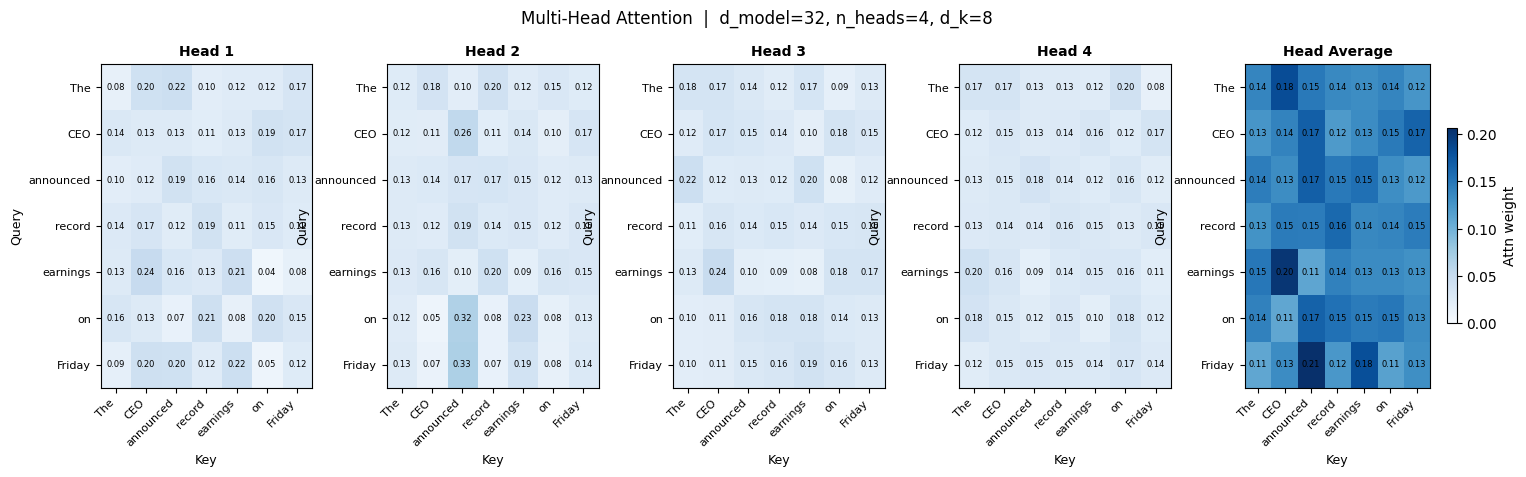

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

torch.manual_seed(42)

tokens  = ["The", "CEO", "announced", "record", "earnings", "on", "Friday"]
seq_len = len(tokens)
d_model = 32
n_heads = 4

x   = torch.randn(1, seq_len, d_model)
mha = MultiHeadAttention(d_model=d_model, n_heads=n_heads)

_, weights = mha(x)                          # (1, n_heads, seq_len, seq_len)
w = weights[0].detach().numpy()              # (n_heads, seq_len, seq_len)
w_avg = w.mean(axis=0)                       # (seq_len, seq_len) — head-averaged

# ── layout: n_heads individual heads + 1 averaged ───────────────────────────
n_cols = n_heads + 1
fig    = plt.figure(figsize=(3.5 * n_cols, 4.2))
gs     = gridspec.GridSpec(1, n_cols, hspace=0.05, wspace=0.35)

def plot_head(ax, matrix, title, vmax=1.0):
    im = ax.imshow(matrix, vmin=0, vmax=vmax, cmap="Blues", aspect="auto")
    ax.set_xticks(range(seq_len)); ax.set_yticks(range(seq_len))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_xlabel("Key", fontsize=9)
    ax.set_ylabel("Query", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=6)
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f"{matrix[i, j]:.2f}",
                    ha="center", va="center", fontsize=6,
                    color="white" if matrix[i, j] > 0.55 else "black")
    return im

for h in range(n_heads):
    ax = fig.add_subplot(gs[0, h])
    plot_head(ax, w[h], f"Head {h + 1}")

ax_avg = fig.add_subplot(gs[0, n_heads])
im_avg = plot_head(ax_avg, w_avg, "Head Average", vmax=w_avg.max())
fig.colorbar(im_avg, ax=ax_avg, fraction=0.046, pad=0.08, label="Attn weight")

plt.suptitle(
    f"Multi-Head Attention  |  d_model={d_model}, n_heads={n_heads}, d_k={d_model // n_heads}",
    fontsize=12, y=1.01,
)
plt.show()

## 6. Self-Attention vs. Multi-Head Attention

MHA is a direct generalization of single-head self-attention — same scaled dot-product core, but parallelized across $h$ independent subspaces with an output projection to recombine results.

$$\underbrace{\text{softmax}\!\left(\frac{XW_Q\,(XW_K)^\top}{\sqrt{d_k}}\right)XW_V}_{\text{single head — output} \in \mathbb{R}^{d_k}} \quad\xrightarrow{\;\times\, h \text{ heads}\;}\quad \underbrace{\text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W_O}_{\text{multi-head — output} \in \mathbb{R}^{d_{\text{model}}}}$$

| Property | Self-Attention | Multi-Head Attention |
|----------|---------------|---------------------|
| Projection matrices | $W_Q, W_K, W_V \in \mathbb{R}^{d_{\text{model}} \times d_k}$ | $W_Q, W_K, W_V \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$ |
| Attention heads | 1 | $h$ |
| $d_k$ per head | user-defined | $d_{\text{model}} / h$ — fixed |
| Weights shape | $(\text{batch},\, \text{seq\_len},\, \text{seq\_len})$ | $(\text{batch},\, h,\, \text{seq\_len},\, \text{seq\_len})$ |
| Output dim | $d_k$ (often $< d_{\text{model}}$) | $d_{\text{model}}$ — always matches input |
| Output projection | None | $W_O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$ |
| Residual-compatible | Only if $d_k = d_{\text{model}}$ | Always |
| Parameters | $3 \cdot d_{\text{model}} \cdot d_k$ | $4 \cdot d_{\text{model}}^2$ |

**What MHA adds over single-head:**
- **Representational diversity** — each head operates in an independent $d_k$-dim subspace, learning to specialize (local syntax, long-range coreference, positional patterns, semantics).
- **Output projection $W_O$** — re-mixes head outputs with a learned linear map. Without it, concatenation loses cross-head interaction.
- **Fixed output shape** — always `(batch, seq_len, d_model)`, identical to the input, so MHA stacks directly with residual connections.

> **Gotchas**
> - Forgetting `.contiguous()` before `.view()` after `.transpose()` raises a runtime error.
> - `d_model` must be divisible by `n_heads`. GPT-2: `d_model=768, n_heads=12` → `d_k=64`. GPT-3: `d_model=12288, n_heads=96` → `d_k=128`.
> - Attention scores are `(batch, n_heads, seq_len, seq_len)` — memory scales quadratically in `seq_len`. At `seq_len=2048, n_heads=32`: ≈ **512 MB** per batch item. This is why Flash Attention exists.

In [7]:
torch.manual_seed(0)

batch, seq_len, d_model, n_heads = 1, 7, 64, 8
d_k = d_model // n_heads  # 8 — same per-head dim as MHA

x = torch.randn(batch, seq_len, d_model)

sa  = SelfAttention(d_model=d_model, d_k=d_k)
mha = MultiHeadAttention(d_model=d_model, n_heads=n_heads)

out_sa,  w_sa  = sa(x)
out_mha, w_mha = mha(x)

param_sa  = sum(p.numel() for p in sa.parameters())
param_mha = sum(p.numel() for p in mha.parameters())

col_w = 22
header = f"{'Property':<{col_w}} {'Self-Attention':>16}  {'Multi-Head Attn':>18}"
sep    = "─" * len(header)
rows = [
    ("Input shape",         tuple(x.shape),        tuple(x.shape)),
    ("Output shape",        tuple(out_sa.shape),    tuple(out_mha.shape)),
    ("Weights shape",       tuple(w_sa.shape),      tuple(w_mha.shape)),
    ("Attention heads",     1,                      n_heads),
    ("d_k per head",        d_k,                    mha.d_k),
    ("Output projection",   "No",                   "Yes (W_O)"),
    ("Residual-compatible", "Only if d_k=d_model",  "Always"),
    ("# parameters",        param_sa,               param_mha),
]

print(sep)
print(header)
print(sep)
for label, sa_val, mha_val in rows:
    print(f"{label:<{col_w}} {str(sa_val):>16}  {str(mha_val):>18}")
print(sep)

───────────────────────────────────────────────────────────
Property                 Self-Attention     Multi-Head Attn
───────────────────────────────────────────────────────────
Input shape                  (1, 7, 64)          (1, 7, 64)
Output shape                  (1, 7, 8)          (1, 7, 64)
Weights shape                 (1, 7, 7)        (1, 8, 7, 7)
Attention heads                       1                   8
d_k per head                          8                   8
Output projection                    No           Yes (W_O)
Residual-compatible    Only if d_k=d_model              Always
# parameters                       1536               16384
───────────────────────────────────────────────────────────
